## Import required libraries

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

2026-05-01 21:10:26.088115: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777669826.300444      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777669826.360805      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777669826.897538      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777669826.897623      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777669826.897626      16 computation_placer.cc:177] computation placer alr

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/masou

## DATA CONFIGURATION

In [3]:
data_dir = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
batch_size = 32
img_height = 128
img_width = 128

## LOAD TRAINING AND VALIDATION DATA

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


2026-05-01 21:11:00.857621: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


## BUILD THE CNN MODEL ARCHITECTURE

In [6]:
model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  
  layers.Dense(4) 
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## COMPILE THE MODEL

In [7]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

## TRAIN THE MODEL

In [8]:
print("Starting training...")
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Starting training...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 545ms/step - accuracy: 0.5713 - loss: 1.1394 - val_accuracy: 0.8107 - val_loss: 0.4453
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 512ms/step - accuracy: 0.8572 - loss: 0.4019 - val_accuracy: 0.8250 - val_loss: 0.4293
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 510ms/step - accuracy: 0.9095 - loss: 0.2505 - val_accuracy: 0.8625 - val_loss: 0.3520
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 77s 547ms/step - accuracy: 0.9525 - loss: 0.1359 - val_accuracy: 0.8670 - val_loss: 0.3674
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 511ms/step - accuracy: 0.9735 - loss: 0.0844 - val_accuracy: 0.9268 - val_loss: 0.2346
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 512ms/step - accuracy: 0.9910 - loss: 0.0306 - val_accuracy: 0.9161 - val_loss: 0.2911
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 554ms/step - accuracy: 0.9954 - loss: 0.0209 - val_accuracy: 0.8964 - val_loss: 0.3398
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 517ms/step - accur

## Testing

In [9]:
test_dir = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'

test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

test_loss, test_acc = model.evaluate(test_ds)

Found 1600 files belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.8584 - loss: 1.5683


In [10]:
# final test accuracy
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8550


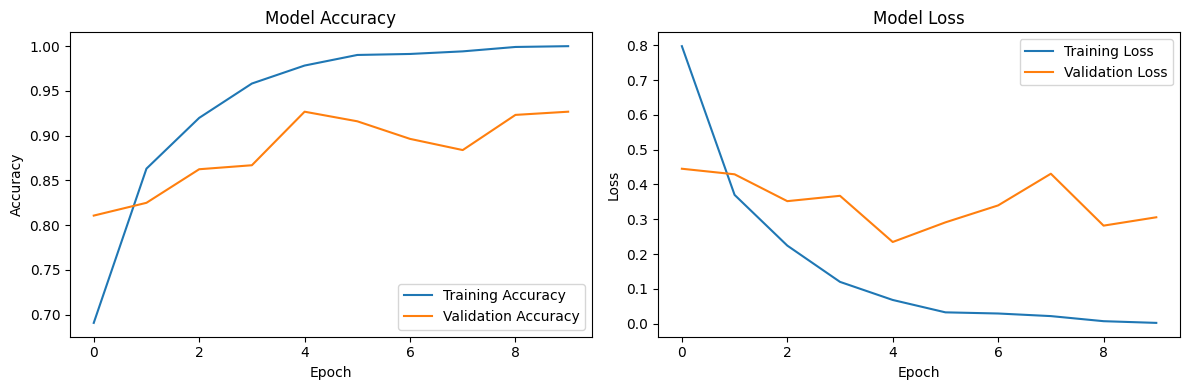

In [11]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## TEST THE TUMOR DETECTOR

TESTING TUMOR DETECTOR

Testing on Glioma Tumor Image:


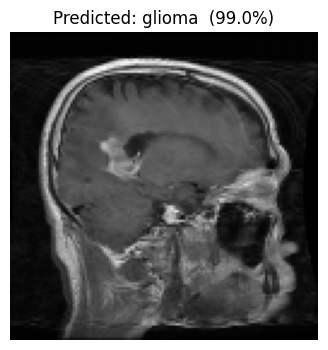

In [12]:
class_names_orig = train_ds.class_names

def predict_and_show(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(img_height, img_width))
    img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), axis=0)
    preds = model.predict(img_array, verbose=0)
    idx  = np.argmax(preds[0])
    conf = tf.nn.softmax(preds[0]).numpy()[idx] * 100
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted: {class_names_orig[idx]}  ({conf:.1f}%)')
    plt.show()

print('TESTING TUMOR DETECTOR')

test_image_glioma = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma/Te-gl_101.jpg'
if os.path.exists(test_image_glioma):
    print('\nTesting on Glioma Tumor Image:')
    predict_and_show(test_image_glioma)
else:
    print(f'\nFile not found: {test_image_glioma}')

## Confusion matrix and Classification report

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

class_names = train_ds.class_names

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:')
print(cm)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

Confusion Matrix:
[[306  39  44  11]
 [ 49 314  20  17]
 [  0   3 397   0]
 [ 16  33   0 351]]

Classification Report:
              precision    recall  f1-score   support

      glioma       0.82      0.77      0.79       400
  meningioma       0.81      0.79      0.80       400
     notumor       0.86      0.99      0.92       400
   pituitary       0.93      0.88      0.90       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.85      1600
weighted avg       0.85      0.85      0.85      1600



## _______ IMPROVED APPROACH ________________________

Key improvements over the original:
- **EfficientNetB0** pretrained on ImageNet (1.2M images)
- **Data augmentation** to reduce overfitting
- **Two-phase training** (head first, then fine-tune)
- **Dropout + BatchNormalization** for regularization
- **ReduceLROnPlateau + EarlyStopping** callbacks
- **Fixed `predict_and_show`** with proper confidence scores

## Import Additional Libraries

In [14]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## DATA CONFIGURATION

In [15]:
data_dir    = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
test_dir    = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'

BATCH_SIZE  = 32
IMG_HEIGHT  = 224   # EfficientNetB0 expects 224x224
IMG_WIDTH   = 224
NUM_CLASSES = 4

## LOAD TRAINING AND VALIDATION DATA

In [16]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print('Classes:', class_names)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## DATA AUGMENTATION

Applying augmentation only on training data to reduce overfitting and improve generalization on unseen scans.

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## BUILD THE TRANSFER LEARNING MODEL

EfficientNetB0 is used as the backbone (pretrained on ImageNet). We remove its original top and attach a custom classification head for 4 brain tumor classes.

In [18]:
# Load EfficientNetB0 without the top classification layers
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Phase 1: Freeze the base — train only the new head first
base_model.trainable = False

# Build model
inputs  = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_v2 = tf.keras.Model(inputs, outputs)
model_v2.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,039 (16.85 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## PHASE 1 — TRAIN THE HEAD ONLY (5 epochs)

With the EfficientNetB0 base frozen, we train only the new Dense layers. This stabilizes the head weights before fine-tuning.

In [19]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 1: Training head only...')
history_phase1 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Phase 1: Training head only...
Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.6396 - loss: 0.9708 - val_accuracy: 0.7661 - val_loss: 0.5829
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.8222 - loss: 0.4613 - val_accuracy: 0.7688 - val_loss: 0.5192
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.8541 - loss: 0.3696 - val_accuracy: 0.7598 - val_loss: 0.6112
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.8672 - loss: 0.3426 - val_accuracy: 0.7821 - val_loss: 0.6209
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.9009 - loss: 0.2725 - val_accuracy: 0.8241 - val_loss: 0.4577


## PHASE 2 — FINE-TUNING THE ENTIRE NETWORK (up to 15 more epochs)

We unfreeze the base model and retrain end-to-end with a very small learning rate so the ImageNet features adapt gently to brain MRI data.

In [20]:
base_model.trainable = True
print(f'Total layers in base model: {len(base_model.layers)}')

# Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 2: Fine-tuning entire network...')
history_phase2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[reduce_lr, early_stop]
)

Total layers in base model: 238
Phase 2: Fine-tuning entire network...
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 831s 6s/step - accuracy: 0.7673 - loss: 0.6342 - val_accuracy: 0.8929 - val_loss: 0.3154 - learning_rate: 1.0000e-04
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 767s 5s/step - accuracy: 0.9238 - loss: 0.2062 - val_accuracy: 0.8964 - val_loss: 0.2927 - learning_rate: 1.0000e-04
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 762s 5s/step - accuracy: 0.9606 - loss: 0.1190 - val_accuracy: 0.9027 - val_loss: 0.3031 - learning_rate: 1.0000e-04
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 749s 5s/step - accuracy: 0.9765 - loss: 0.0717 - val_accuracy: 0.8902 - val_loss: 0.3273 - learning_rate: 1.0000e-04
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9851 - loss: 0.0491
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
140/140 ━━━━━━━━━━━━━━━━━━━━ 748s 5s/step - accuracy: 0.9851 - loss: 0.0491 - val_accuracy: 0.8964 - val_loss: 0.3542 - learning_rate: 1.00

## COMBINE TRAINING HISTORY & PLOT

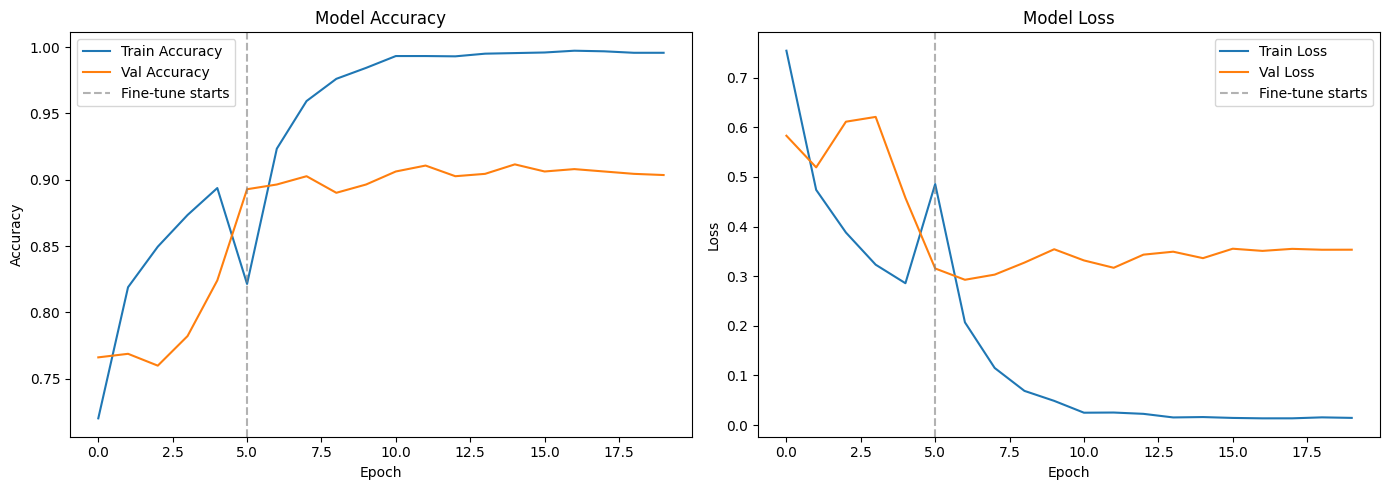

In [21]:
acc      = history_phase1.history['accuracy']     + history_phase2.history['accuracy']
val_acc  = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss     = history_phase1.history['loss']         + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss']     + history_phase2.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc,     label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(x=5, color='gray', linestyle='--', alpha=0.6, label='Fine-tune starts')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss,     label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=5, color='gray', linestyle='--', alpha=0.6, label='Fine-tune starts')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## EVALUATE ON TEST SET

In [22]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
).cache().prefetch(buffer_size=AUTOTUNE)

test_loss, test_acc = model_v2.evaluate(test_ds)
print(f'\nTest Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Test Loss:     {test_loss:.4f}')

Found 1600 files belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8777 - loss: 0.6647

Test Accuracy: 0.8806  (88.06%)
Test Loss:     0.6046


## PREDICT AND SHOW

TESTING TUMOR DETECTOR

Testing on Glioma Tumor Image:


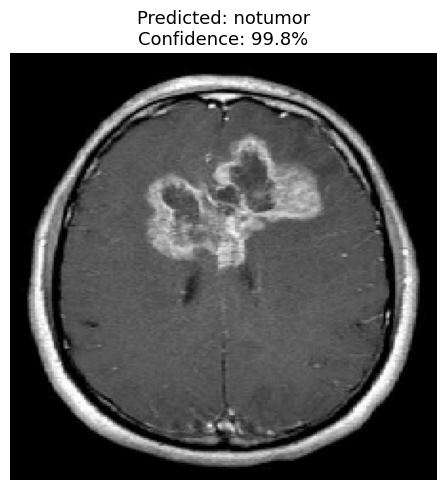

  All scores: {'glioma': '0.0%', 'meningioma': '0.2%', 'notumor': '99.8%', 'pituitary': '0.0%'}

Testing on No-Tumor Image:


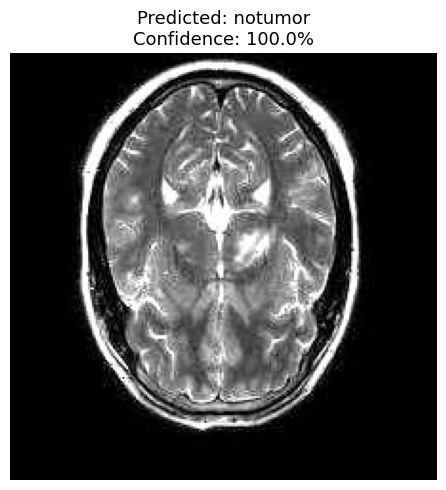

  All scores: {'glioma': '0.0%', 'meningioma': '0.0%', 'notumor': '100.0%', 'pituitary': '0.0%'}


In [23]:
def predict_and_show(image_path):
    """Load an image, run inference, and display the result with confidence."""
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )
    img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), axis=0)

    predictions    = model_v2.predict(img_array, verbose=0)
    predicted_idx  = np.argmax(predictions[0])
    predicted_class = class_names[predicted_idx]
    confidence     = predictions[0][predicted_idx] * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f'Predicted: {predicted_class}\nConfidence: {confidence:.1f}%',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    print(f"  All scores: { {class_names[i]: f'{predictions[0][i]*100:.1f}%' for i in range(NUM_CLASSES)} }")
    return predicted_class, confidence


print('TESTING TUMOR DETECTOR')

test_image_glioma = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma/Te-gl_1.jpg'
if os.path.exists(test_image_glioma):
    print('\nTesting on Glioma Tumor Image:')
    predict_and_show(test_image_glioma)
else:
    print(f'File not found: {test_image_glioma}')

test_image_notumor = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/notumor/Te-no_10.jpg'
if os.path.exists(test_image_notumor):
    print('\nTesting on No-Tumor Image:')
    predict_and_show(test_image_notumor)
else:
    print(f'File not found: {test_image_notumor}')

## CONFUSION MATRIX & CLASSIFICATION REPORT

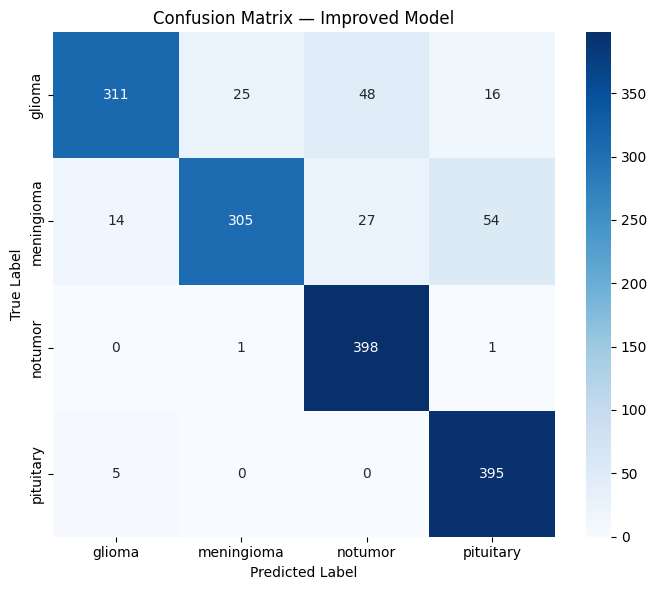


Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.78      0.85       400
  meningioma       0.92      0.76      0.83       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.85      0.99      0.91       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



In [24]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_v2.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix — Improved Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))